In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

In [2]:
ds = load_dataset("Tobi-Bueck/customer-support-tickets")
df = ds["train"].to_pandas()

In [3]:
df["text"] = df["subject"].fillna("") + " " + df["body"].fillna("")

df = df[df["language"] == "en"].copy()

df = df[["text", "queue", "priority"]]

df.reset_index(drop=True, inplace=True)

print("Total English samples:", len(df))
print("\nQueue distribution:\n")
print(df["queue"].value_counts())

Total English samples: 28261

Queue distribution:

queue
Technical Support                  8149
Product Support                    5305
Customer Service                   4269
IT Support                         3333
Billing and Payments               2897
Returns and Exchanges              1402
Service Outages and Maintenance    1106
Sales and Pre-Sales                 843
Human Resources                     553
General Inquiry                     404
Name: count, dtype: int64



Basic Length Stats:
count    28261.000000
mean        60.364318
std         31.328463
min          1.000000
25%         35.000000
50%         59.000000
75%         83.000000
max        276.000000
Name: word_count, dtype: float64


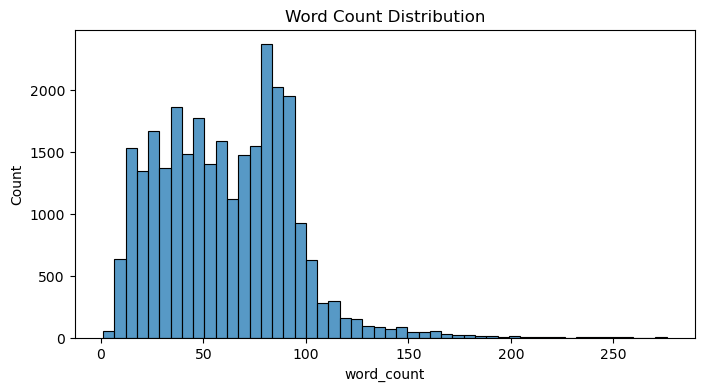


Number of tickets with <5 words: 17

Examples of very short tickets:
['Issue Encountered Assistance Needed' ' Problems with the server'
 ' Several products are impacted' ' Several products are impacted.'
 ' Hello support team' ' Seek assistance with billing'
 ' Seeking assistance with billing' ' Issues with software integration'
 'ConcernregardingSystemInvestmentAnalytics Thecompanyisincapableofaccessinginvestmentanalyticsduetosystemunavailability.'
 ' Problems with software integration']


In [4]:
df["word_count"] = df["text"].apply(lambda x: len(str(x).split()))

print("\nBasic Length Stats:")
print(df["word_count"].describe())

# Plot distribution
plt.figure(figsize=(8,4))
sns.histplot(df["word_count"], bins=50)
plt.title("Word Count Distribution")
plt.show()

# Show very short tickets
short_samples = df[df["word_count"] < 5]
print("\nNumber of tickets with <5 words:", len(short_samples))

print("\nExamples of very short tickets:")
print(short_samples["text"].head(10).values)

In [5]:
# Exact duplicates
duplicate_count = df.duplicated(subset=["text"]).sum()
print("Exact duplicate count:", duplicate_count)

# Remove exact duplicates
df_no_dup = df.drop_duplicates(subset=["text"]).copy()
print("Size after removing duplicates:", len(df_no_dup))

Exact duplicate count: 4513
Size after removing duplicates: 23748


In [6]:
df["normalized_text"] = df["text"].str.lower().str.strip()

duplicate_norm = df.duplicated(subset=["normalized_text"]).sum()
print("Duplicate count after normalization:", duplicate_norm)

Duplicate count after normalization: 4514


In [7]:
cross_label_duplicates = df.groupby("normalized_text")["queue"].nunique()
ambiguous = cross_label_duplicates[cross_label_duplicates > 1]

print("Number of texts assigned to multiple queues:", len(ambiguous))

Number of texts assigned to multiple queues: 0


In [8]:
df_clean = df[df["word_count"] >= 5].copy()
print("Size after removing short tickets:", len(df_clean))

Size after removing short tickets: 28244


In [9]:
def clean_text(text):
    text = re.sub(r"<.*?>", " ", text)  # remove HTML tags
    text = re.sub(r"http\S+", " ", text)  # remove URLs
    text = re.sub(r"\s+", " ", text)  # normalize spaces
    return text.strip()

df_clean["text"] = df_clean["text"].apply(clean_text)

print("Example cleaned text:")
print(df_clean["text"].iloc[0])

Example cleaned text:
Account Disruption Dear Customer Support Team,\n\nI am writing to report a significant problem with the centralized account management portal, which currently appears to be offline. This outage is blocking access to account settings, leading to substantial inconvenience. I have attempted to log in multiple times using different browsers and devices, but the issue persists.\n\nCould you please provide an update on the outage status and an estimated time for resolution? Also, are there any alternative ways to access and manage my account during this downtime?


Size after removing duplicates + short tickets: 23654


C:\Users\nethr\AppData\Local\Temp\ipykernel_27700\2539878450.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), 1000), random_state=42))


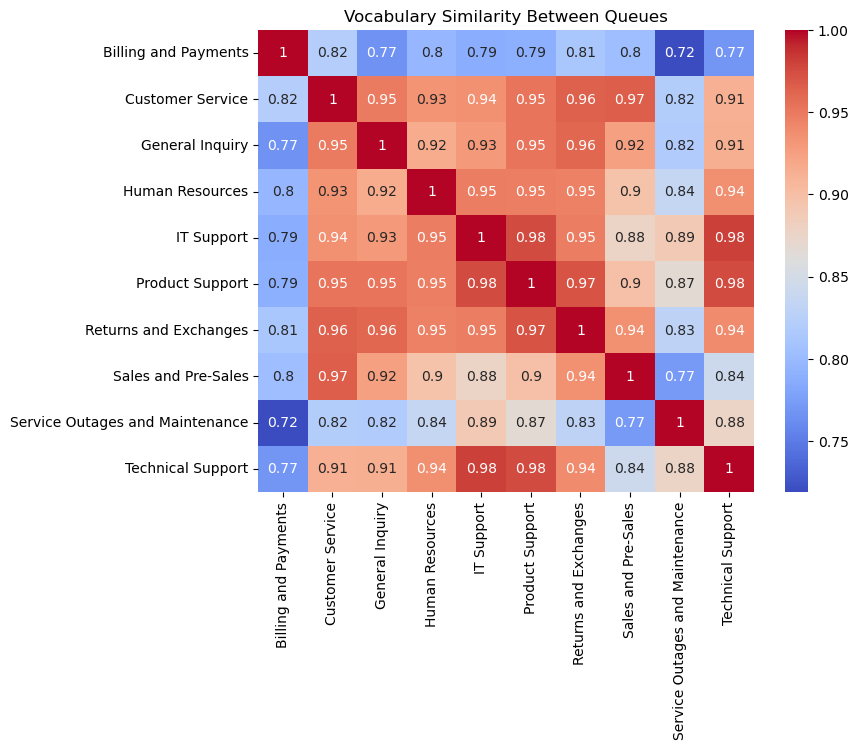

In [12]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Use deduplicated + cleaned dataset
df_analysis = df.drop_duplicates(subset=["normalized_text"]).copy()

df_analysis = df_analysis.copy()
df_analysis["word_count"] = df_analysis["text"].apply(lambda x: len(str(x).split()))

df_analysis = df_analysis[df_analysis["word_count"] >= 8]

print("Size after removing duplicates + short tickets:", len(df_analysis))
# Sample up to 1000 per class
sampled = (
    df_analysis.groupby("queue", group_keys=False)
    .apply(lambda x: x.sample(min(len(x), 1000), random_state=42))
)

vectorizer = CountVectorizer(stop_words="english", max_features=3000)
X = vectorizer.fit_transform(sampled["text"])

queue_labels = sampled["queue"].values
class_names = sampled["queue"].unique()

class_vectors = []

for cls in class_names:
    class_mean = X[queue_labels == cls].mean(axis=0)
    class_vectors.append(np.asarray(class_mean).ravel())

class_vectors = np.vstack(class_vectors)

similarity_matrix = cosine_similarity(class_vectors)

plt.figure(figsize=(8,6))
sns.heatmap(similarity_matrix,
            xticklabels=class_names,
            yticklabels=class_names,
            annot=True,
            cmap="coolwarm")
plt.title("Vocabulary Similarity Between Queues")
plt.xticks(rotation=90)
plt.show()

In [13]:
import random

target_classes = ["IT Support", "Technical Support", "Product Support"]

for cls in target_classes:
    print(f"\n\n===== {cls} =====")
    samples = df_analysis[df_analysis["queue"] == cls]["text"].sample(10, random_state=42)
    for i, text in enumerate(samples, 1):
        print(f"\n--- Sample {i} ---")
        print(text[:500])



===== IT Support =====

--- Sample 1 ---
Incident Report: Data Breach Due to Malware Attack A data breach incident has occurred, potentially compromising sensitive medical data systems due to a malware attack targeting outdated software. Despite immediately scanning the systems with Malwarebytes updated software, the threats still persist. Investigations are ongoing to secure network systems and prevent future incidents. We are working diligently to resolve the issue and ensure the security systems are robust.

--- Sample 2 ---
Request for Information on Integrating Zoho CRM with Project Management SaaS Dear Customer Support Team, I am reaching out to inquire about the process of integrating Zoho CRM with our project management SaaS. Could you provide detailed information on the steps and requirements needed for this integration? I would greatly appreciate any guidance and resources that could help me get started. Additionally, I would like to know more about the specific features an

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Focus only on the 3 overlapping classes
subset_classes = ["IT Support", "Technical Support", "Product Support"]

df_subset = df_analysis[df_analysis["queue"].isin(subset_classes)].copy()

X_train, X_test, y_train, y_test = train_test_split(
    df_subset["text"],
    df_subset["queue"],
    test_size=0.3,
    random_state=42,
    stratify=df_subset["queue"]
)

vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_vec, y_train)

y_pred = clf.predict(X_test_vec)

print(classification_report(y_test, y_pred))

                   precision    recall  f1-score   support

       IT Support       0.55      0.23      0.32       848
  Product Support       0.56      0.46      0.50      1324
Technical Support       0.57      0.78      0.66      2050

         accuracy                           0.57      4222
        macro avg       0.56      0.49      0.50      4222
     weighted avg       0.56      0.57      0.54      4222



In [17]:
import pandas as pd
from datasets import load_dataset

# Reload full dataset
ds = load_dataset("Tobi-Bueck/customer-support-tickets")
df_full = ds["train"].to_pandas()

# Keep only English for now
df_full = df_full[df_full["language"] == "en"].copy()

df_full.reset_index(drop=True, inplace=True)

print("Columns in dataset:")
print(df_full.columns)
print("\nTotal English samples:", len(df_full))

Columns in dataset:
Index(['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language',
       'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6',
       'tag_7', 'tag_8'],
      dtype='object')

Total English samples: 28261


In [18]:
for col in df_full.columns:
    print(col)

subject
body
answer
type
queue
priority
language
version
tag_1
tag_2
tag_3
tag_4
tag_5
tag_6
tag_7
tag_8


In [20]:
# Crosstab: Queue vs Type
type_queue = pd.crosstab(df_full["queue"], df_full["type"])

print(type_queue)

print("\nType proportions per queue:")
print(type_queue.div(type_queue.sum(axis=1), axis=0))

type                             Change  Incident  Problem  Request
queue                                                              
Billing and Payments                169       688      618     1422
Customer Service                    347      1103      875     1944
General Inquiry                     109       130       71       94
Human Resources                      39       280       65      169
IT Support                          586      1165      873      709
Product Support                     623      2300     1190     1192
Returns and Exchanges               174       553      279      396
Sales and Pre-Sales                 158       162      112      411
Service Outages and Maintenance     255       614       69      168
Technical Support                   530      4218     1743     1658

Type proportions per queue:
type                               Change  Incident   Problem   Request
queue                                                                  
Billing and

In [23]:
# Combine tags into single string per row
tag_cols = [col for col in df_full.columns if "tag_" in col]

df_full["combined_tags"] = df_full[tag_cols].astype(str).agg(" ".join, axis=1)

# Crosstab Queue vs Combined Tags
tag_queue_counts = df_full.groupby("queue")["combined_tags"].value_counts().head(20)

print(tag_queue_counts)

queue                 combined_tags                                                
Billing and Payments  Feedback Sales IT Tech Support None None None None               76
                      Security IT Tech Support Documentation None None None None       41
                      Security Documentation IT Tech Support None None None None       25
                      Feature Documentation IT Tech Support None None None None        24
                      Security IT Tech Support None None None None None                23
                      Feature Feedback IT Tech Support None None None None             18
                      Feedback IT Tech Support None None None None None                14
                      Security IT Tech Support Alert None None None None               14
                      Billing Payment Refund Disruption Tech Support None None None    13
                      Billing Refund Payment Account None None None None               13
                

In [24]:
from collections import Counter

def top_tags_for_queue(queue_name, top_n=5):
    subset = df_full[df_full["queue"] == queue_name]
    tags = []
    for col in tag_cols:
        tags.extend(subset[col].dropna().tolist())
    return Counter(tags).most_common(top_n)

for q in df_full["queue"].unique():
    print(f"\n=== {q} ===")
    print(top_tags_for_queue(q))


=== Technical Support ===
[('Tech Support', 4746), ('IT', 4667), ('Performance', 4023), ('Bug', 2933), ('Security', 2041)]

=== Returns and Exchanges ===
[('Tech Support', 622), ('IT', 585), ('Performance', 584), ('Feedback', 567), ('Bug', 415)]

=== Billing and Payments ===
[('Billing', 1681), ('Payment', 1344), ('Tech Support', 957), ('Feedback', 897), ('IT', 788)]

=== Sales and Pre-Sales ===
[('Feedback', 423), ('Tech Support', 366), ('IT', 355), ('Feature', 319), ('Documentation', 294)]

=== Service Outages and Maintenance ===
[('IT', 657), ('Tech Support', 640), ('Outage', 608), ('Disruption', 586), ('Performance', 548)]

=== Product Support ===
[('Tech Support', 2657), ('IT', 2581), ('Performance', 2389), ('Feedback', 1944), ('Bug', 1610)]

=== IT Support ===
[('IT', 1847), ('Tech Support', 1841), ('Performance', 1514), ('Bug', 936), ('Feedback', 854)]

=== Customer Service ===
[('Tech Support', 2164), ('IT', 2117), ('Feedback', 1735), ('Documentation', 1518), ('Performance', 1

In [25]:
pd.crosstab(df_full["version"], df_full["queue"])

queue,Billing and Payments,Customer Service,General Inquiry,Human Resources,IT Support,Product Support,Returns and Exchanges,Sales and Pre-Sales,Service Outages and Maintenance,Technical Support
version,,,,,,,,,,
51.0,45,77,13,12,55,114,16,21,28,170
52.0,456,734,76,106,710,1066,265,188,206,1539
400.0,1094,1599,147,230,1177,1893,539,304,430,3028


In [26]:
pd.crosstab(df_full["queue"], df_full["priority"])

priority,high,low,medium
queue,,,
Billing and Payments,846,615,1436
Customer Service,789,1403,2077
General Inquiry,66,239,99
Human Resources,58,263,232
IT Support,1580,329,1424
Product Support,1600,1012,2693
Returns and Exchanges,315,517,570
Sales and Pre-Sales,150,304,389
Service Outages and Maintenance,776,141,189
